# Hellinger ETW syntax demo

In [1]:
import sys, time
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulate_etw_data import simulate_pair, rbf_similarity, rbf_similarity_matrix
from hellinger_etw import etw_align as etw_fast
from hellinger_etw_original import etw_align_original as etw_original

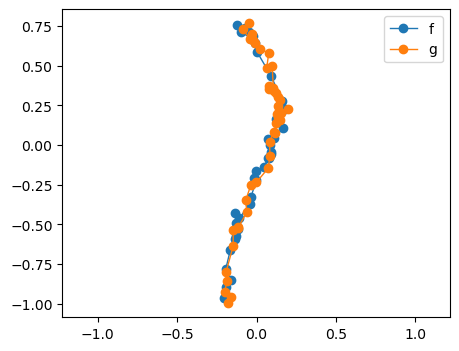

In [7]:
pair = simulate_pair(n=40, m=45, kind="integrated_random_walk", seed=0, noise=0.02)
C = rbf_similarity_matrix(pair.f_values, pair.g_values, sigma=0.25)

plt.figure(figsize=(5, 4))
plt.plot(pair.f_values[:, 0], pair.f_values[:, 1], marker="o", linewidth=1, label="f")
plt.plot(pair.g_values[:, 0], pair.g_values[:, 1], marker="o", linewidth=1, label="g")
plt.axis("equal")
plt.legend()
plt.show()

In [3]:
fast = etw_fast(
    pair.f_values,
    pair.f_times,
    pair.g_values,
    pair.g_times,
    similarity_matrix=C,
)

original = etw_original(
    pair.f_values,
    pair.f_times,
    pair.g_values,
    pair.g_times,
    similarity_matrix=C,
)

print("fast score:    ", fast.score)
print("original score:", original.score)
print("abs diff:      ", abs(fast.score - original.score))
assert np.allclose(fast.score, original.score)

fast.pairs[:12]

fast score:     0.9681462387282326
original score: 0.9681462387282326
abs diff:       0.0


[(0, 0),
 (1, 0),
 (2, 1),
 (3, 1),
 (4, 1),
 (5, 2),
 (5, 3),
 (6, 4),
 (7, 5),
 (7, 6),
 (8, 7),
 (8, 8)]

In [4]:
Cfun = rbf_similarity(sigma=0.25)
fast_callable = etw_fast(
    pair.f_values,
    pair.f_times,
    pair.g_values,
    pair.g_times,
    similarity=Cfun,
)

np.allclose(fast_callable.score, fast.score)

True

In [11]:
%%time
# Warm up Numba outside the timings.
warm = simulate_pair(8, 8, seed=999, noise=0.02)
Cwarm = rbf_similarity_matrix(warm.f_values, warm.g_values, sigma=0.25)
_ = etw_fast(warm.f_values, warm.f_times, warm.g_values, warm.g_times, similarity_matrix=Cwarm)
_ = etw_original(warm.f_values, warm.f_times, warm.g_values, warm.g_times, similarity_matrix=Cwarm)


def benchmark(n, seed):
    p = simulate_pair(n, n, seed=seed, noise=0.02, warp_strength=0.7, grid_size=2048)
    Cn = rbf_similarity_matrix(p.f_values, p.g_values, sigma=0.25)

    t0 = time.perf_counter()
    r_fast = etw_fast(p.f_values, p.f_times, p.g_values, p.g_times, similarity_matrix=Cn)
    fast_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    r_original = etw_original(p.f_values, p.f_times, p.g_values, p.g_times, similarity_matrix=Cn)
    original_s = time.perf_counter() - t0

    return {
        "n=m": n,
        "fast_s": fast_s,
        "original_s": original_s,
        "speedup": original_s / fast_s,
        "score_abs_diff": abs(r_fast.score - r_original.score),
    }

sizes = [32*(x+1) for x in range(60)]
df = pd.DataFrame([benchmark(n, n) for n in sizes])
df.head()

CPU times: user 5min 43s, sys: 2.39 s, total: 5min 46s
Wall time: 5min 45s


,n=m,fast_s,original_s,speedup,score_abs_diff
0,32,0.000125,0.000126,1.008380,0.000000e+00
1,64,0.000382,0.000599,1.568929,1.110223e-16
2,96,0.000823,0.001817,2.208236,1.110223e-16
3,128,0.001314,0.004127,3.142336,1.110223e-16
4,160,0.002000,0.007897,3.948945,2.220446e-16


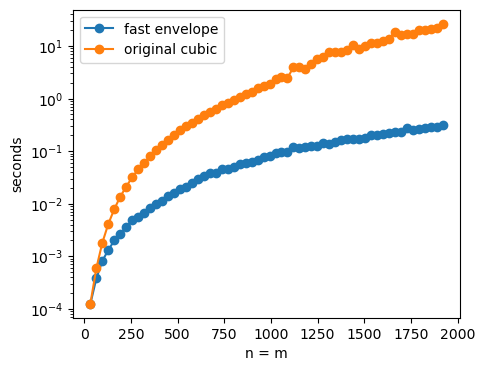

In [12]:
plt.figure(figsize=(5, 4))
plt.plot(df["n=m"], df["fast_s"], marker="o", label="fast envelope")
plt.plot(df["n=m"], df["original_s"], marker="o", label="original cubic")
plt.xlabel("n = m")
plt.ylabel("seconds")
plt.yscale("log")
plt.legend()
plt.show()

In [14]:
import numpy as np
import pandas as pd

d = df.copy()
d = d[d["n=m"] >= 300]   # ignore small-n overhead / JIT effects

for col in ["fast_s", "original_s"]:
    x = np.log(d["n=m"].to_numpy())
    y = np.log(d[col].to_numpy())
    p, logC = np.polyfit(x, y, 1)
    print(col, "estimated exponent:", p)

fast_s estimated exponent: 2.1296652431149714
original_s estimated exponent: 3.4633558397347777


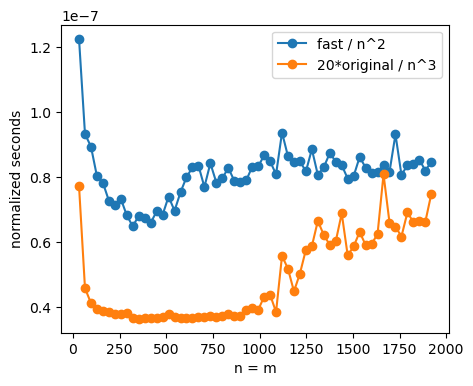

In [17]:
df["fast_over_n2"] = df["fast_s"] / (df["n=m"] ** 2)
df["original_over_n3"] = 20*df["original_s"] / (df["n=m"] ** 3)

plt.figure(figsize=(5, 4))
plt.plot(df["n=m"], df["fast_over_n2"], marker="o", label="fast / n^2")
plt.plot(df["n=m"], df["original_over_n3"], marker="o", label="20*original / n^3")
plt.xlabel("n = m")
plt.ylabel("normalized seconds")
plt.legend()
plt.show()